In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = "/kaggle/input/severity-dataset-fire/severity_dataset_CNN"

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(f"{data_dir}/train", transform=train_transform)
valid_dataset = datasets.ImageFolder(f"{data_dir}/valid", transform=val_test_transform)
test_dataset  = datasets.ImageFolder(f"{data_dir}/test",  transform=val_test_transform)


***Data Preprocessing***

In [5]:
# ==========================================
# ✅ PART 1: ONE-TIME DATA SETUP (FOR ALL MODELS)
# ==========================================

import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision.datasets import ImageFolder
from torchvision import transforms
from collections import Counter
import numpy as np

# -----------------------------
# 1️⃣ Device setup
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2️⃣ Define transforms
# -----------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# -----------------------------
# 3️⃣ Load datasets (UPDATE PATHS)
# -----------------------------
train_dataset = ImageFolder(root="/kaggle/input/severity-dataset-fire/severity_dataset_CNN/train",
                            transform=train_transform)
valid_dataset = ImageFolder(root="/kaggle/input/severity-dataset-fire/severity_dataset_CNN/valid",
                            transform=val_transform)
test_dataset = ImageFolder(root="/kaggle/input/severity-dataset-fire/severity_dataset_CNN/test",
                           transform=val_transform)

class_names = train_dataset.classes
print("📂 Classes:", class_names)

# -----------------------------
# 4️⃣ Compute class weights
# -----------------------------
labels = train_dataset.targets
class_counts = Counter(labels)
print("📊 Class distribution:", class_counts)

# class weights = inverse of class frequency
num_classes = len(class_counts)
total_samples = len(train_dataset)
class_weights = [total_samples / (num_classes * class_counts[i]) for i in range(num_classes)]
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("⚖️ Class Weights:", weights_tensor)

# -----------------------------
# 5️⃣ Weighted Random Sampler
# -----------------------------
sample_weights = [class_weights[label] for label in labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# -----------------------------
# 6️⃣ Dataloaders
# -----------------------------
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# -----------------------------
# ✅ Final Output
# -----------------------------
print("\n✅ Data setup complete! Ready to train models.")
print(f"Train images: {len(train_dataset)} | Val images: {len(valid_dataset)} | Test images: {len(test_dataset)}")


Using device: cuda
📂 Classes: ['Mild', 'Moderate', 'Severe']
📊 Class distribution: Counter({1: 6851, 2: 4094, 0: 2478})
⚖️ Class Weights: tensor([1.8056, 0.6531, 1.0929], device='cuda:0')

✅ Data setup complete! Ready to train models.
Train images: 13423 | Val images: 1277 | Test images: 637


**CNN Final Model**

✅ Using device: cuda
Classes: ['Mild', 'Moderate', 'Severe']
Epoch [1/25] Train Acc: 52.25% | Val Acc: 55.05%
Epoch [2/25] Train Acc: 55.55% | Val Acc: 56.54%
Epoch [3/25] Train Acc: 58.24% | Val Acc: 57.09%
Epoch [4/25] Train Acc: 58.85% | Val Acc: 57.01%
Epoch [5/25] Train Acc: 60.39% | Val Acc: 59.75%
Epoch [6/25] Train Acc: 61.86% | Val Acc: 64.60%
Epoch [7/25] Train Acc: 63.47% | Val Acc: 62.65%
Epoch [8/25] Train Acc: 64.06% | Val Acc: 63.74%
Epoch [9/25] Train Acc: 65.40% | Val Acc: 65.47%
Epoch [10/25] Train Acc: 66.56% | Val Acc: 65.47%
Epoch [11/25] Train Acc: 66.53% | Val Acc: 66.17%
Epoch [12/25] Train Acc: 66.37% | Val Acc: 66.17%
Epoch [13/25] Train Acc: 66.11% | Val Acc: 65.86%
Epoch [14/25] Train Acc: 65.94% | Val Acc: 66.64%
Epoch [15/25] Train Acc: 65.72% | Val Acc: 63.27%
Epoch [16/25] Train Acc: 66.04% | Val Acc: 66.17%
Epoch [17/25] Train Acc: 65.87% | Val Acc: 66.95%
Epoch [18/25] Train Acc: 65.53% | Val Acc: 67.58%
Epoch [19/25] Train Acc: 65.78% | Val Acc: 63.82

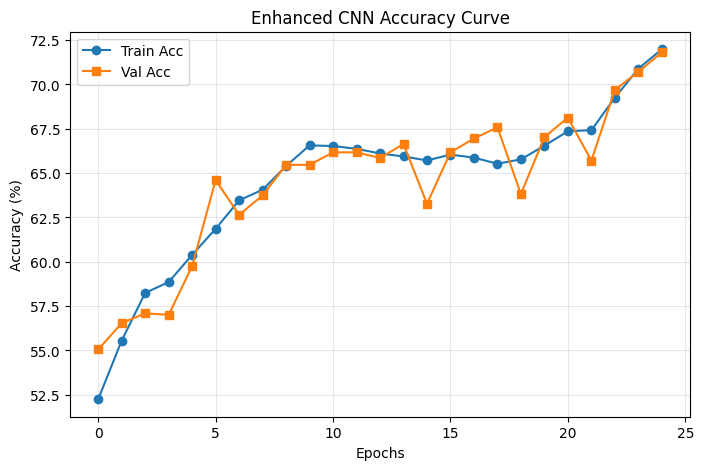

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import copy
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# ------------------------
# 1. Device setup
# ------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

# ------------------------
# 2. Data transforms with stronger augmentation
# ------------------------
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomResizedCrop(128, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ------------------------
# 3. Dataset paths
# ------------------------
train_dir = "/kaggle/input/severity-dataset-fire/severity_dataset_CNN/train"
val_dir   = "/kaggle/input/severity-dataset-fire/severity_dataset_CNN/valid"
test_dir  = "/kaggle/input/severity-dataset-fire/severity_dataset_CNN/test"

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data   = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_data  = datasets.ImageFolder(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=4)

print("Classes:", train_data.classes)

# ------------------------
# 4. Enhanced CNN Model
# ------------------------
class EnhancedCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(EnhancedCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = EnhancedCNN(num_classes=3).to(device)

# ------------------------
# 5. Loss, Optimizer, Scheduler
# ------------------------
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# ------------------------
# 6. Training Loop with Early Stopping
# ------------------------
epochs = 25
patience = 4
best_val_acc = 0.0
counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

train_acc_history, val_acc_history = [], []

for epoch in range(epochs):
    model.train()
    correct, total, running_loss = 0, 0, 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        running_loss += loss.item()

    train_acc = 100 * correct / total
    train_acc_history.append(train_acc)

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_acc_history.append(val_acc)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
        torch.save(model.state_dict(), "enhanced_cnn_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("⚠️ Early stopping triggered!")
        break

# Load best model
model.load_state_dict(best_model_wts)

# ------------------------
# 7. Test Evaluation
# ------------------------
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_acc = 100 * np.sum(np.array(y_true) == np.array(y_pred)) / len(y_true)
print(f"\n✅ Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"✅ Test Accuracy: {test_acc:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=train_data.classes))

# ------------------------
# 8. Plot Accuracy Curve
# ------------------------
plt.figure(figsize=(8,5))
plt.plot(train_acc_history, label="Train Acc", marker='o')
plt.plot(val_acc_history, label="Val Acc", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Enhanced CNN Accuracy Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Resnet18 Final Model**

✅ Using device: cuda
Classes: ['Mild', 'Moderate', 'Severe']
Class weights: [1.8056228 0.653092  1.0929002]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]
/tmp/ipykernel_37/3409930127.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/12 [Validation]: 100%|██████████| 40/40 [00:12<00:00,  3.10it/s]


Epoch 1/12 | Train Loss: 1.0804 Acc: 0.4748 | Val Loss: 1.1863 Acc: 0.3156 | Time: 117.3s
✅ Best model saved (Val Acc: 0.3156)


Epoch 2/12 [Validation]: 100%|██████████| 40/40 [00:11<00:00,  3.37it/s]


Epoch 2/12 | Train Loss: 0.8672 Acc: 0.6273 | Val Loss: 1.1963 Acc: 0.3038 | Time: 116.3s


...

Epoch 8/12 | Train Loss: 0.5110 Acc: 0.8966 | Val Loss: 1.0331 Acc: 0.4965 | Time: 116.6s


Epoch 9/12 [Validation]: 100%|██████████| 40/40 [00:12<00:00,  3.32it/s]


Epoch 9/12 | Train Loss: 0.4908 Acc: 0.9126 | Val Loss: 1.0238 Acc: 0.5255 | Time: 116.7s
⏹ Early stopping triggered.

🎯 Training complete. Best Val Acc: 0.5654


Testing: 100%|██████████| 20/20 [00:04<00:00,  4.32it/s]



✅ Test Accuracy: 75.67%

Classification Report:
              precision    recall  f1-score   support

        Mild     0.7206    0.7717    0.7452       127
    Moderate     0.8160    0.7209    0.7655       326
      Severe     0.6995    0.8098    0.7506       184

    accuracy                         0.7567       637
   macro avg     0.7454    0.7674    0.7538       637
weighted avg     0.7633    0.7567    0.7572       637


Confusion Matrix:
 [[ 98  21   8]
 [ 35 235  56]
 [  3  32 149]]


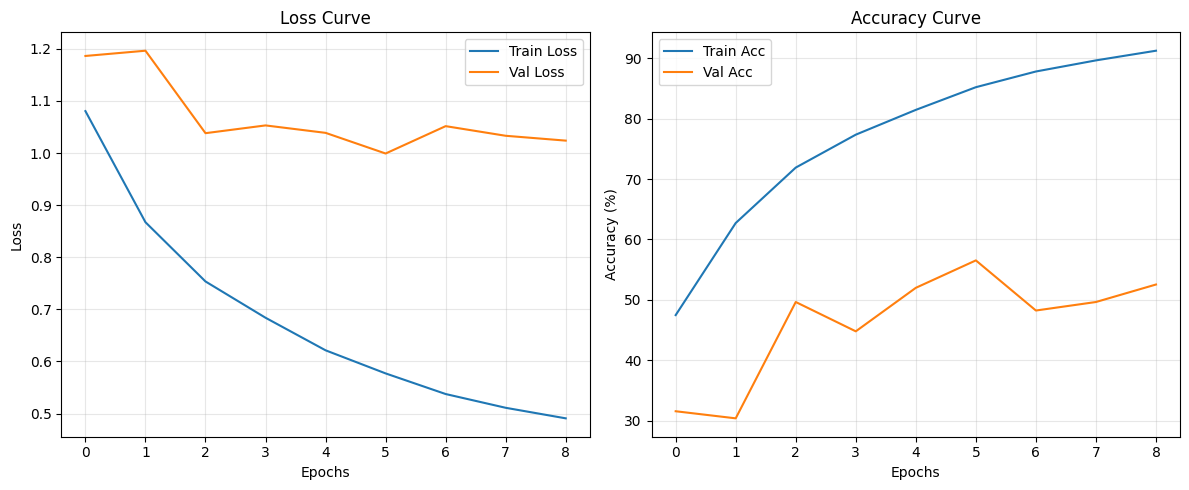


✅ Model Saved as: resnet18_finetuned_best_v2.pth


In [11]:
# ==========================================
# ENHANCED RESNET18 FINE-TUNING (Target: 80–85% Accuracy)
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import time, copy, os
from tqdm import tqdm

# --------------------------
# DEVICE SETUP
# --------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)


# --------------------------
# CHECK REQUIRED VARIABLES
# --------------------------
try:
    train_loader, valid_loader, test_loader
except NameError:
    raise RuntimeError("Please define train_loader, valid_loader, and test_loader first!")

if 'class_names' not in globals():
    class_names = train_loader.dataset.classes

if 'weights_tensor' not in globals():
    # Compute class weights if not available
    labels = [y for _, y in train_loader.dataset.samples]
    counts = np.bincount(labels)
    class_weights = 1.0 / counts
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    print("Computed class weights:", class_weights)

print("Classes:", class_names)
print("Class weights:", weights_tensor.cpu().numpy())

# --------------------------
# MODEL DEFINITION
# --------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_ftrs, len(class_names))
)
model = model.to(device)

# --------------------------
# UNFREEZE SELECTIVE LAYERS
# --------------------------
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last two layers (layer3 & layer4)
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

# --------------------------
# LOSS, OPTIMIZER & SCHEDULER
# --------------------------
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)
optimizer = optim.AdamW([
    {'params': model.layer3.parameters(), 'lr': 5e-5},
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 2e-4}
], weight_decay=1e-4)

# OneCycleLR dynamically adjusts LR
num_epochs = 12
steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[5e-5, 1e-4, 2e-4],
    steps_per_epoch=steps_per_epoch,
    epochs=num_epochs,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=100
)

scaler = torch.cuda.amp.GradScaler()

# --------------------------
# TRAINING LOOP
# --------------------------
def train_model(model, train_loader, valid_loader, epochs=12, patience=3):
    best_val_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        start_time = time.time()
        model.train()

        running_loss, running_corrects, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data).item()
            total += labels.size(0)

        epoch_train_loss = running_loss / total
        epoch_train_acc = running_corrects / total
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # --------------------------
        # VALIDATION
        # --------------------------
        model.eval()
        val_loss, val_corrects, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]"):
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.amp.autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data).item()
                val_total += labels.size(0)

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_corrects / val_total
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f} | Time: {time.time()-start_time:.1f}s")

        # --------------------------
        # Save best model
        # --------------------------
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
            torch.save(best_wts, "resnet18_finetuned_best_v2.pth")
            print(f"✅ Best model saved (Val Acc: {best_val_acc:.4f})")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("⏹ Early stopping triggered.")
            break

    model.load_state_dict(best_wts)
    print(f"\n🎯 Training complete. Best Val Acc: {best_val_acc:.4f}")
    return model, best_val_acc, train_losses, val_losses, train_accs, val_accs

# Train model
model, best_val_acc, train_losses, val_losses, train_accs, val_accs = train_model(model, train_loader, valid_loader, epochs=num_epochs, patience=3)

# --------------------------
# EVALUATION ON TEST DATA
# --------------------------
def evaluate_model(model, test_loader, class_names):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Testing"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    print(f"\n✅ Test Accuracy: {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:\n", cm)
    return acc

# Evaluate model
test_acc = evaluate_model(model, test_loader, class_names)

# --------------------------
# PLOT LEARNING CURVES
# --------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Loss Curve')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(np.array(train_accs)*100, label='Train Acc')
plt.plot(np.array(val_accs)*100, label='Val Acc')
plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)'); plt.title('Accuracy Curve')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("resnet18_training_curves_v2.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Model Saved as: resnet18_finetuned_best_v2.pth")


**EfficientNetB0 (Final Model)**

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

✅ Using device: cuda
📊 Class weights: [1.8056228 0.653092  1.0929002]


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch 1/20 | Train Loss: 1.2141 Acc: 0.6657 | Val Loss: 1.3484 Acc: 0.6014
✅ Best model saved (Val Acc: 0.6014)
Epoch 2/20 | Train Loss: 0.6012 Acc: 0.7923 | Val Loss: 1.0682 Acc: 0.6735
✅ Best model saved (Val Acc: 0.6735)
Epoch 3/20 | Train Loss: 0.5100 Acc: 0.8395 | Val Loss: 1.0285 Acc: 0.6719
Epoch 4/20 | Train Loss: 0.4549 Acc: 0.8771 | Val Loss: 0.9720 Acc: 0.6899
✅ Best model saved (Val Acc: 0.6899)
Epoch 5/20 | Train Loss: 0.4287 Acc: 0.9032 | Val Loss: 0.8904 Acc: 0.7322
✅ Best model saved (Val Acc: 0.7322)
Epoch 6/20 | Train Loss: 0.4048 Acc: 0.9184 | Val Loss: 0.8979 Acc: 0.7400
✅ Best model saved (Val Acc: 0.7400)
Epoch 7/20 | Train Loss: 0.3846 Acc: 0.9334 | Val Loss: 0.9033 Acc: 0.7439
✅ Best model saved (Val Acc: 0.7439)
Epoch 8/20 | Train Loss: 0.3712 Acc: 0.9400 | Val Loss: 0.8615 Acc: 0.7674
✅ Best model saved (Val Acc: 0.7674)
Epoch 9/20 | Train Loss: 0.3609 Acc: 0.9509 | Val Loss: 0.8847 Acc: 0.7439
Epoch 10/20 | Train Loss: 0.3485 Acc: 0.9595 | Val Loss: 0.8906 Ac

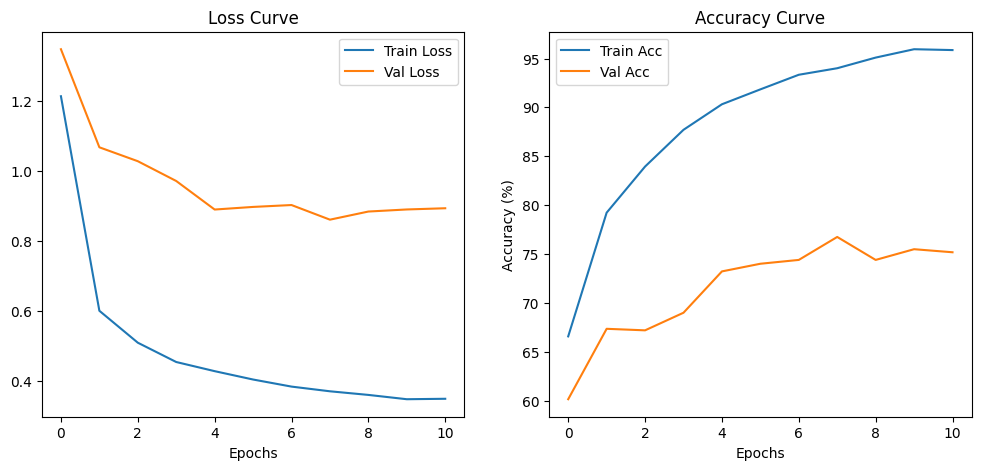

🎯 Best Validation Accuracy: 76.74%
✅ Test Accuracy: 76.77% | Weighted F1: 76.84%
              precision    recall  f1-score   support

        Mild       0.70      0.80      0.74       127
    Moderate       0.82      0.74      0.78       326
      Severe       0.74      0.79      0.76       184

    accuracy                           0.77       637
   macro avg       0.75      0.78      0.76       637
weighted avg       0.77      0.77      0.77       637



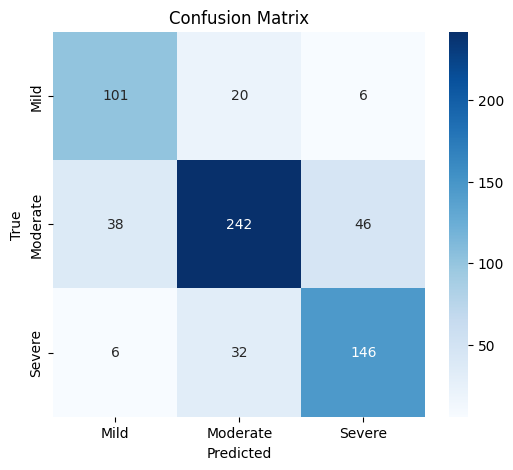

In [1]:
# ============================================================
# 🔥 EfficientNet-B0 for Fire Severity Classification
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import datasets
import timm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np
from collections import Counter
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
from torch.amp import GradScaler, autocast
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

# ============================================================
# DATA AUGMENTATION
# ============================================================
train_transform = A.Compose([
    A.Resize(224, 224),
    A.RandomCrop(200, 200, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ============================================================
# CUSTOM DATASET
# ============================================================
class FireDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_folder = datasets.ImageFolder(root_dir)
        self.transform = transform
        self.samples = self.image_folder.samples
        self.targets = self.image_folder.targets

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        try:
            image = Image.open(path).convert("RGB")
            image = np.array(image)
            if self.transform:
                augmented = self.transform(image=image)
                image = augmented['image']
            return image, target
        except:
            return torch.zeros(3, 224, 224), target

def custom_collate(batch):
    images, labels = [], []
    for img, lbl in batch:
        if img.shape == (3, 224, 224):
            images.append(img)
            labels.append(lbl)
    if not images:
        return torch.zeros(0, 3, 224, 224), torch.tensor([])
    return torch.stack(images), torch.tensor(labels)

# ============================================================
# LOAD DATASETS
# ============================================================
train_dir = '/kaggle/input/severity-dataset-fire/severity_dataset_CNN/train'
val_dir   = '/kaggle/input/severity-dataset-fire/severity_dataset_CNN/valid'
test_dir  = '/kaggle/input/severity-dataset-fire/severity_dataset_CNN/test'

train_dataset = FireDataset(train_dir, transform=train_transform)
val_dataset   = FireDataset(val_dir, transform=val_transform)
test_dataset  = FireDataset(test_dir, transform=val_transform)

# ============================================================
# HANDLE CLASS IMBALANCE
# ============================================================
class_counts = Counter(train_dataset.targets)
num_classes = len(class_counts)
class_weights = [len(train_dataset) / (num_classes * class_counts[i]) for i in range(num_classes)]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("📊 Class weights:", class_weights.cpu().numpy())

weights = [class_weights[label] for label in train_dataset.targets]
sampler = torch.utils.data.WeightedRandomSampler(weights, len(weights))

# ============================================================
# DATALOADERS
# ============================================================
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler,
                          num_workers=4, pin_memory=True, collate_fn=custom_collate)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=4, pin_memory=True, collate_fn=custom_collate)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         num_workers=4, pin_memory=True, collate_fn=custom_collate)

# ============================================================
# MODEL: EfficientNet-B0
# ============================================================
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=15)
scaler = GradScaler('cuda')

# ============================================================
# TRAINING FUNCTION
# ============================================================
def train_model(model, train_loader, val_loader, epochs=20, patience=3):
    best_val_loss = float('inf')
    best_val_acc = 0.0
    early_stop = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_preds, train_labels = 0, [], []
        for images, labels in train_loader:
            if images.size(0) == 0: continue
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
            train_preds.extend(outputs.argmax(1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        train_acc = accuracy_score(train_labels, train_preds)
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # ------------------ VALIDATION ------------------
        model.eval()
        val_loss, val_preds, val_labels = 0, [], []
        with torch.no_grad():
            for images, labels in val_loader:
                if images.size(0) == 0: continue
                images, labels = images.to(device), labels.to(device)
                with autocast(device_type='cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_preds.extend(outputs.argmax(1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        scheduler.step()

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "/kaggle/working/efficientnet_best.pth")
            early_stop = 0
            print(f"✅ Best model saved (Val Acc: {val_acc:.4f})")
        else:
            early_stop += 1
            if early_stop >= patience:
                print("⏹ Early stopping triggered.")
                break

    # Plot curves
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title("Loss Curve"); plt.legend(); plt.xlabel("Epochs")

    plt.subplot(1,2,2)
    plt.plot(np.array(train_accs)*100, label='Train Acc')
    plt.plot(np.array(val_accs)*100, label='Val Acc')
    plt.title("Accuracy Curve"); plt.legend(); plt.xlabel("Epochs"); plt.ylabel("Accuracy (%)")
    plt.show()

    print(f"🎯 Best Validation Accuracy: {best_val_acc*100:.2f}%")
    return best_val_acc

# ============================================================
# TRAIN MODEL
# ============================================================
train_model(model, train_loader, val_loader, epochs=20, patience=3)

# ============================================================
# EVALUATE MODEL
# ============================================================
model.load_state_dict(torch.load("/kaggle/working/efficientnet_best.pth"))
model.eval()
preds, labels = [], []
with torch.no_grad():
    for images, lbls in test_loader:
        if images.size(0) == 0: continue
        images = images.to(device)
        with autocast(device_type='cuda'):
            outputs = model(images)
        preds.extend(outputs.argmax(1).cpu().numpy())
        labels.extend(lbls.cpu().numpy())

acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds, average='weighted')
cm = confusion_matrix(labels, preds)

print(f"✅ Test Accuracy: {acc*100:.2f}% | Weighted F1: {f1*100:.2f}%")
print(classification_report(labels, preds, target_names=train_dataset.image_folder.classes))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.image_folder.classes,
            yticklabels=train_dataset.image_folder.classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()
